<a href="https://colab.research.google.com/github/kevdb1/microgrid-energy-optimization/blob/main/Microgrid_Project_26Summer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pypsa highspy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.0/369.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.4 MB/s eta 0:00:00


/tmp/ipykernel_785/3526374741.py:45: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Electricity Bus'], dtype='object', name='name')


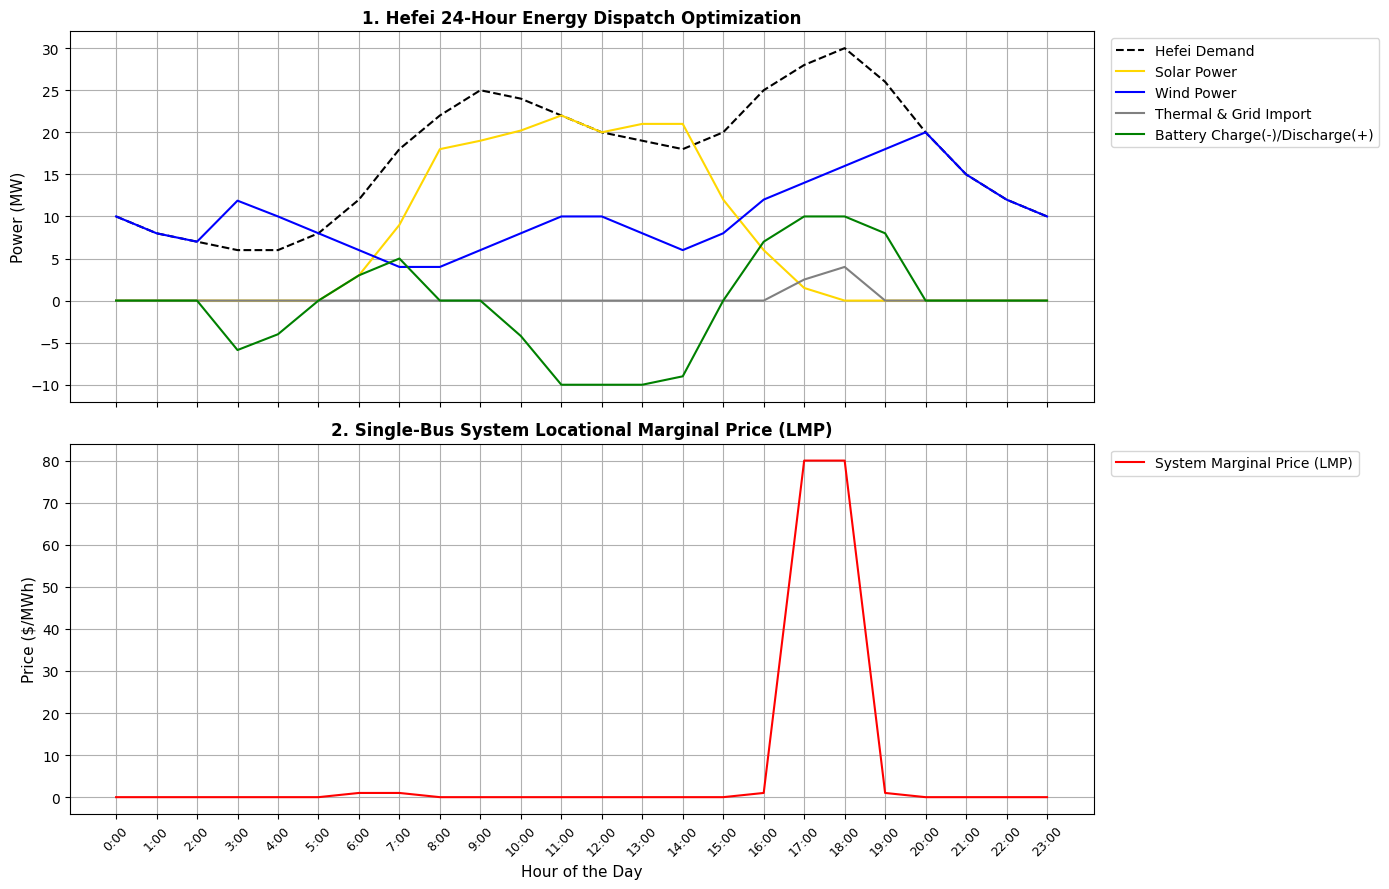

In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

network = pypsa.Network()

hours = pd.date_range("2024-07-01 00:00", periods=24, freq="h")
network.set_snapshots(hours)

network.add("Bus", "Electricity Bus")

load_profile = [10, 8, 7, 6, 6, 8, 12, 18, 22, 25, 24, 22, 20, 19, 18, 20, 25, 28, 30, 26, 20, 15, 12, 10]
network.add("Load", "City Load",
            bus="Electricity Bus",
            p_set=load_profile)

network.add("Generator", "Gas Power Plant",
            bus="Electricity Bus",
            p_nom=50,
            marginal_cost=80)

solar_profile = [0, 0, 0, 0, 0, 0, 0.1, 0.3, 0.6, 0.8, 0.9, 1.0, 0.95, 0.85, 0.7, 0.4, 0.2, 0.05, 0, 0, 0, 0, 0, 0]
network.add("Generator", "Solar Plant",
            bus="Electricity Bus",
            p_nom=30,
            marginal_cost=0,
            p_max_pu=solar_profile)

wind_profile = [0.8, 0.9, 0.85, 0.7, 0.5, 0.4, 0.3, 0.2, 0.2, 0.3, 0.4, 0.5, 0.5, 0.4, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0, 0.95, 0.9, 0.85]
network.add("Generator", "Wind Plant",
            bus="Electricity Bus",
            p_nom=20,
            marginal_cost=0,
            p_max_pu=wind_profile)

network.add("StorageUnit", "Battery",
            bus="Electricity Bus",
            p_nom=10,
            max_hours=4,
            efficiency_store=0.9,
            efficiency_dispatch=0.9,
            marginal_cost=1)

network.optimize(solver_name='highs')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

generators_p = network.generators_t.p
storage_p = network.storage_units_t.p
single_bus_lmp = network.buses_t.marginal_price["Electricity Bus"]
hours_x = range(24)

ax1.plot(hours_x, network.loads_t.p["City Load"], 'k--', label="Hefei Demand", linewidth=1.5)
ax1.plot(hours_x, generators_p["Solar Plant"], label="Solar Power", color='gold', linewidth=1.5)
ax1.plot(hours_x, generators_p["Wind Plant"], label="Wind Power", color='blue', linewidth=1.5)
ax1.plot(hours_x, generators_p["Gas Power Plant"], label="Thermal & Grid Import", color='gray', linewidth=1.5)
ax1.plot(hours_x, storage_p["Battery"], label="Battery Charge(-)/Discharge(+)", color='green', linewidth=1.5)
ax1.set_ylabel("Power (MW)", fontsize=11)
ax1.set_title("1. Hefei 24-Hour Energy Dispatch Optimization", fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax1.grid(True)

ax2.plot(hours_x, single_bus_lmp, color='red', linewidth=1.5, label="System Marginal Price (LMP)")
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=9)
ax2.set_xlabel("Hour of the Day", fontsize=11)
ax2.set_ylabel("Price ($/MWh)", fontsize=11)
ax2.set_title("2. Single-Bus System Locational Marginal Price (LMP)", fontsize=12, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hf_wind.csv to hf_wind.csv
Saving hf_solar.csv to hf_solar.csv


/tmp/ipykernel_651/2796008911.py:62: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Hefei Grid Bus'], dtype='object', name='name')


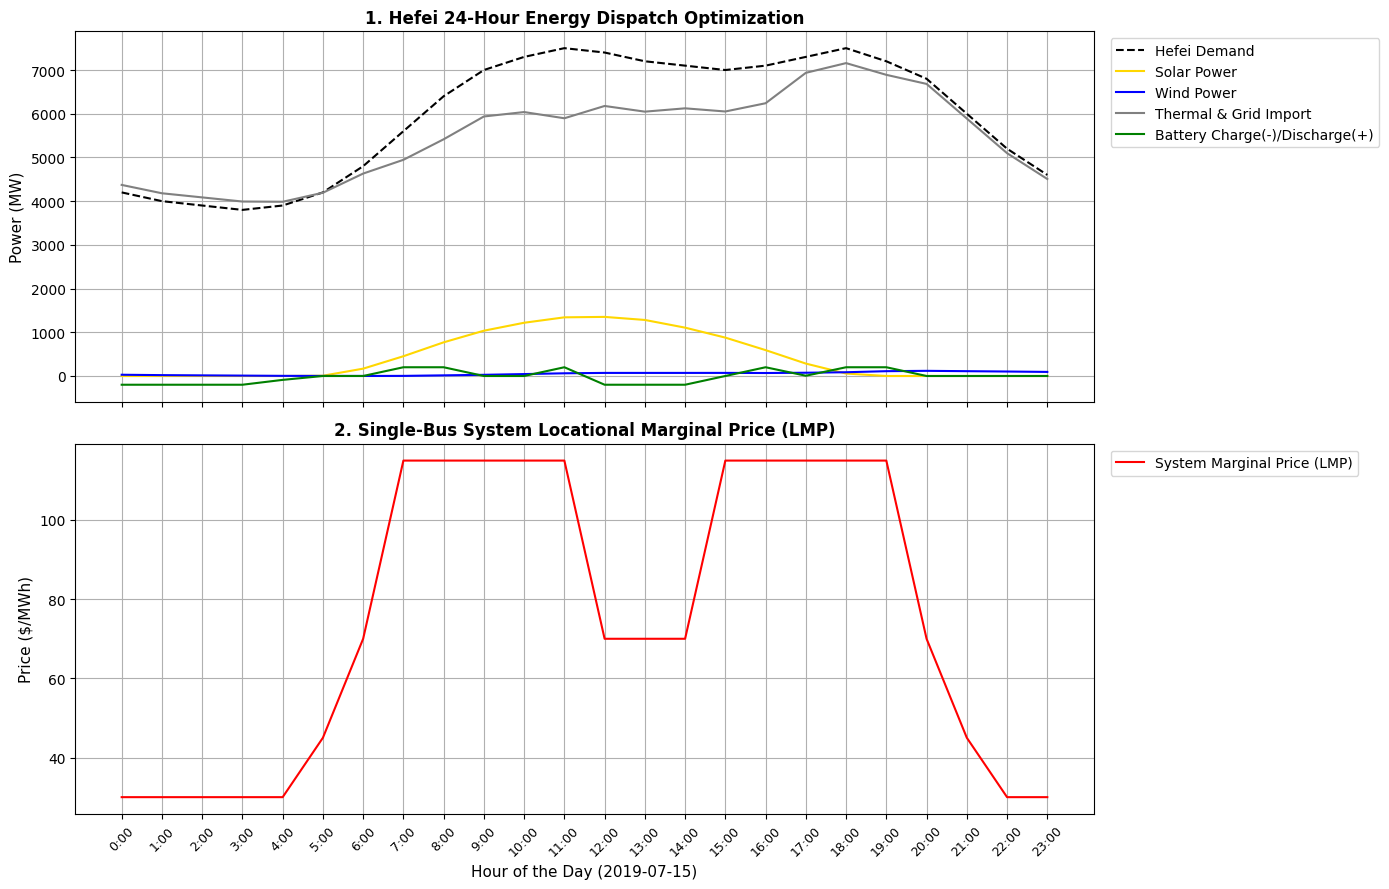

Hefei 2019-07-15 Total lowest electricity generation cost throughout the day: $10,511,111.67


In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_pv = pd.read_csv('hf_solar.csv', skiprows=3, parse_dates=True, index_col=0)
df_wind = pd.read_csv('hf_wind.csv', skiprows=3, parse_dates=True, index_col=0)

df_pv.index = df_pv.index + pd.Timedelta(hours=8)
df_wind.index = df_wind.index + pd.Timedelta(hours=8)

day_pv = df_pv.loc['2019-07-15':'2019-07-15']
day_wind = df_wind.loc['2019-07-15':'2019-07-15']

network = pypsa.Network()
network.set_snapshots(day_pv.index)

network.add("Bus", "Hefei Grid Bus")

hefei_load_curve = [
    4200, 4000, 3900, 3800, 3900, 4200,
    4800, 5600, 6400, 7000, 7300, 7500,
    7400, 7200, 7100, 7000, 7100, 7300,
    7500, 7200, 6800, 6000, 5200, 4600
]

tou_price_usd = [
    30, 30, 30, 30, 30, 45,
    70, 115, 115, 115, 115, 115,
    70, 70, 70,
    115, 115, 115, 115, 115,
    70, 45, 30, 30
]

network.add("Load", "Hefei City Demand", bus="Hefei Grid Bus", p_set=hefei_load_curve)

network.add("Generator", "Thermal Power",
            bus="Hefei Grid Bus",
            p_nom=8000,
            marginal_cost=tou_price_usd)

network.add("Generator", "Solar Power (PV)",
            bus="Hefei Grid Bus",
            p_nom=2000,
            marginal_cost=0,
            p_max_pu=day_pv['electricity'])

network.add("Generator", "Wind Power",
            bus="Hefei Grid Bus",
            p_nom=300,
            marginal_cost=0,
            p_max_pu=day_wind['electricity'])

network.add("StorageUnit", "Battery Storage",
            bus="Hefei Grid Bus",
            p_nom=200,
            max_hours=4,
            efficiency_store=0.9,
            efficiency_dispatch=0.9,
            marginal_cost=1)

network.optimize(solver_name='highs')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

generators_p = network.generators_t.p
storage_p = network.storage_units_t.p
single_bus_lmp = network.buses_t.marginal_price["Hefei Grid Bus"]
hours_x = range(24)

ax1.plot(hours_x, network.loads_t.p["Hefei City Demand"], 'k--', label="Hefei Demand", linewidth=1.5)
ax1.plot(hours_x, generators_p["Solar Power (PV)"], label="Solar Power", color='gold', linewidth=1.5)
ax1.plot(hours_x, generators_p["Wind Power"], label="Wind Power", color='blue', linewidth=1.5)
ax1.plot(hours_x, generators_p["Thermal Power"], label="Thermal & Grid Import", color='gray', linewidth=1.5)
ax1.plot(hours_x, storage_p["Battery Storage"], label="Battery Charge(-)/Discharge(+)", color='green', linewidth=1.5)
ax1.set_ylabel("Power (MW)", fontsize=11)
ax1.set_title("1. Hefei 24-Hour Energy Dispatch Optimization", fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax1.grid(True)

ax2.plot(hours_x, single_bus_lmp, color='red', linewidth=1.5, label="System Marginal Price (LMP)")
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=9)
ax2.set_xlabel("Hour of the Day (2019-07-15)", fontsize=11)
ax2.set_ylabel("Price ($/MWh)", fontsize=11)
ax2.set_title("2. Single-Bus System Locational Marginal Price (LMP)", fontsize=12, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Hefei 2019-07-15 Total lowest electricity generation cost throughout the day: ${network.objective:,.2f}")

/tmp/ipykernel_651/3495831006.py:65: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Hefei Grid Bus'], dtype='object', name='name')


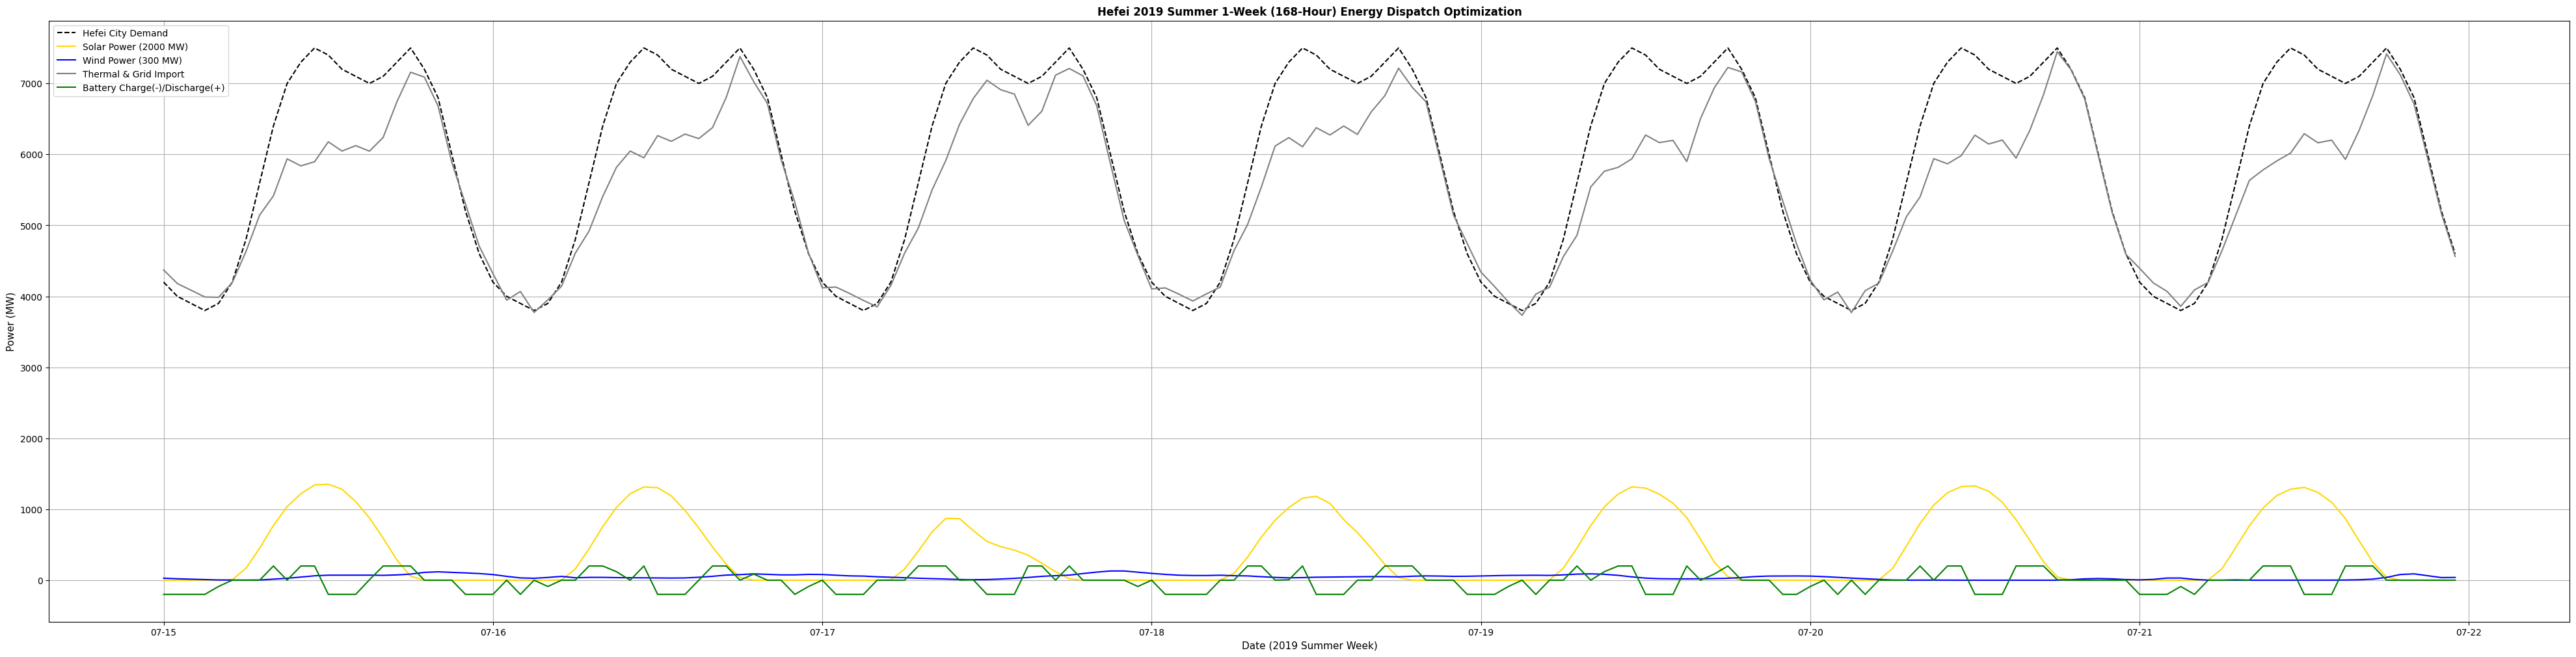

Hefei 2019-07-15 to 2019-07-21 (one week) Lowest total power generation cost: $74,534,499.67 dollars


In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_pv = pd.read_csv('hf_solar.csv', skiprows=3, parse_dates=True, index_col=0)
df_wind = pd.read_csv('hf_wind.csv', skiprows=3, parse_dates=True, index_col=0)

df_pv.index = df_pv.index + pd.Timedelta(hours=8)
df_wind.index = df_wind.index + pd.Timedelta(hours=8)

week_pv = df_pv.loc['2019-07-15':'2019-07-21']
week_wind = df_wind.loc['2019-07-15':'2019-07-21']

network = pypsa.Network()
network.set_snapshots(week_pv.index)

network.add("Bus", "Hefei Grid Bus")

hefei_daily_load = [
    4200, 4000, 3900, 3800, 3900, 4200,
    4800, 5600, 6400, 7000, 7300, 7500,
    7400, 7200, 7100, 7000, 7100, 7300,
    7500, 7200, 6800, 6000, 5200, 4600
]
hefei_week_load = hefei_daily_load * 7

tou_price_usd = [
    30, 30, 30, 30, 30, 45,
    70, 115, 115, 115, 115, 115,
    70, 70, 70,
    115, 115, 115, 115, 115,
    70, 45, 30, 30
]
tou_price = tou_price_usd * 7

network.add("Load", "Hefei Demand", bus="Hefei Grid Bus", p_set=hefei_week_load)

network.add("Generator", "Thermal & Grid Import",
            bus="Hefei Grid Bus",
            p_nom=8000,
            marginal_cost=tou_price)

network.add("Generator", "Solar Power (PV)",
            bus="Hefei Grid Bus",
            p_nom=2000,
            marginal_cost=0,
            p_max_pu=week_pv['electricity'])

network.add("Generator", "Wind Power",
            bus="Hefei Grid Bus",
            p_nom=300,
            marginal_cost=0,
            p_max_pu=week_wind['electricity'])

network.add("StorageUnit", "Battery Storage",
            bus="Hefei Grid Bus",
            p_nom=200,
            max_hours=4,
            efficiency_store=0.9,
            efficiency_dispatch=0.9,
            marginal_cost=1)

network.optimize(solver_name='highs')

fig, ax = plt.subplots(figsize=(50, 12))

generators_p = network.generators_t.p
storage_p = network.storage_units_t.p

ax.plot(network.snapshots, network.loads_t.p["Hefei Demand"], 'k--', label="Hefei City Demand", linewidth=1.5)
ax.plot(network.snapshots, generators_p["Solar Power (PV)"], label="Solar Power (2000 MW)", color='gold', linewidth=1.5)
ax.plot(network.snapshots, generators_p["Wind Power"], label="Wind Power (300 MW)", color='blue', linewidth=1.5)
ax.plot(network.snapshots, generators_p["Thermal & Grid Import"], label="Thermal & Grid Import", color='gray', linewidth=1.5)
ax.plot(network.snapshots, storage_p["Battery Storage"], label="Battery Charge(-)/Discharge(+)", color='green', linewidth=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())

ax.set_xlabel("Date (2019 Summer Week)", fontsize=11)
ax.set_ylabel("Power (MW)", fontsize=11)
ax.set_title("Hefei 2019 Summer 1-Week (168-Hour) Energy Dispatch Optimization", fontsize=12, fontweight='bold')
ax.legend(loc="upper left")
ax.grid(True)

plt.show()

print(f"Hefei 2019-07-15 to 2019-07-21 (one week) Lowest total power generation cost: ${network.objective:,.2f} dollars")

/tmp/ipykernel_785/1382231116.py:57: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Electricity Bus'], dtype='object', name='name')


1. Optimal Gas Capacity (Gas Cap)  : 16.19 MW
2. Optimal Solar Capacity (Solar Cap) : 32.00 MW (Under Limit)
3. Optimal Wind Capacity (Wind Cap)  : 8.04 MW (Under Limit)
4. Optimal Battery Capacity (Battery Cap): 13.41 MW


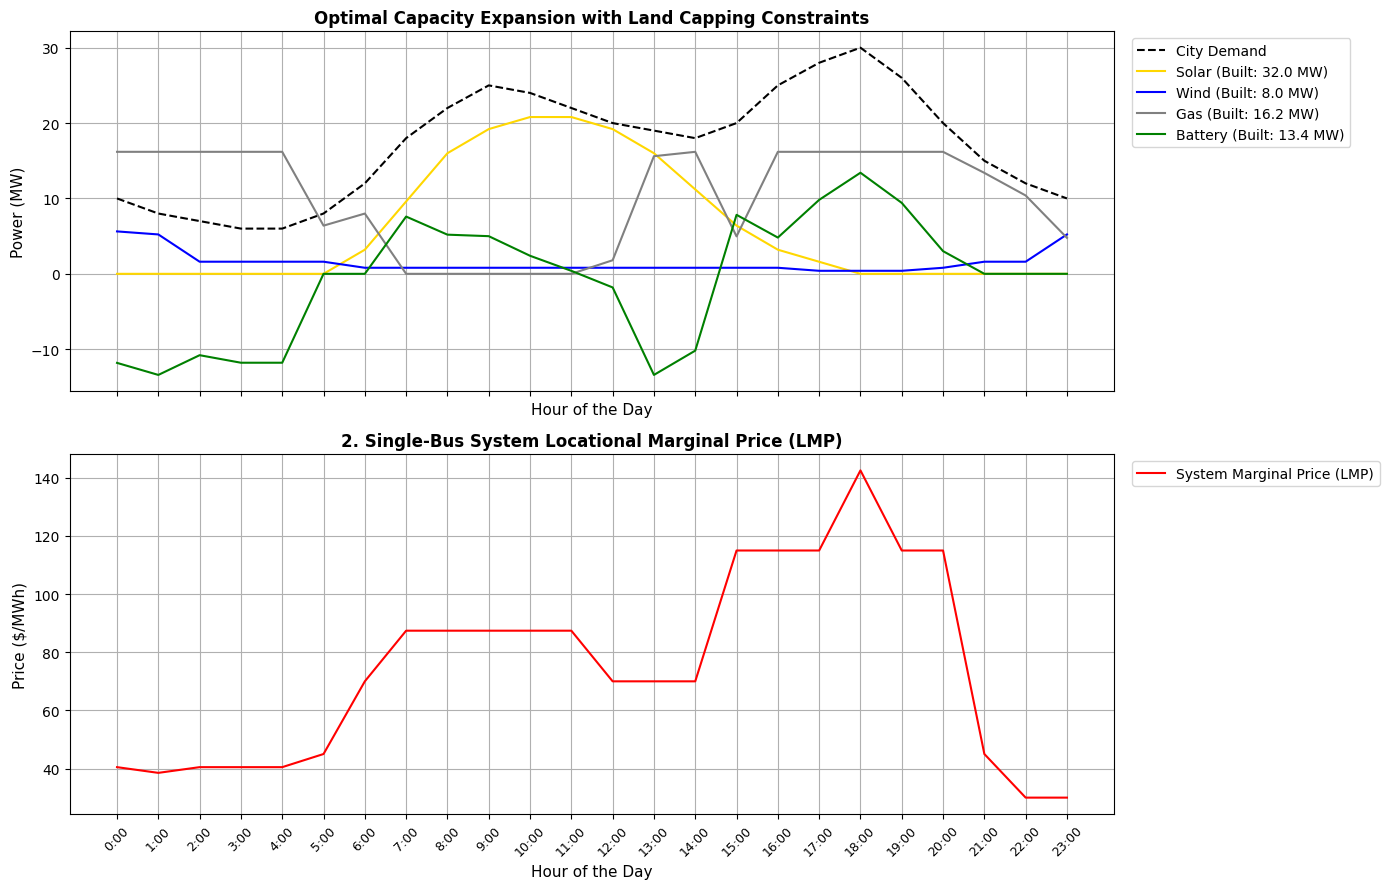

In [ ]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

hours = pd.date_range("2024-07-01 00:00", periods=24, freq="h")

network = pypsa.Network()
network.set_snapshots(hours)

network.add("Bus", "Electricity Bus")

load_profile = [10, 8, 7, 6, 6, 8, 12, 18, 22, 25, 24, 22, 20, 19, 18, 20, 25, 28, 30, 26, 20, 15, 12, 10]
network.add("Load", "City Load", bus="Electricity Bus", p_set=load_profile)

solar_profile = [0, 0, 0, 0, 0, 0, 0.1, 0.3, 0.5, 0.6, 0.65, 0.65, 0.6, 0.5, 0.35, 0.2, 0.1, 0.05, 0, 0, 0, 0, 0, 0]
wind_profile = [0.7, 0.65, 0.2, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.2, 0.2, 0.65]

tou_price_usd = [
    30, 30, 30, 30, 30, 45,
    70, 115, 115, 115, 115, 115,
    70, 70, 70,
    115, 115, 115, 115, 115,
    70, 45, 30, 30
]

network.add("Generator", "Gas Power Plant",
            bus="Electricity Bus",
            capital_cost=123,
            marginal_cost=tou_price_usd,
            p_nom_extendable=True)

network.add("Generator", "Solar Plant",
            bus="Electricity Bus",
            capital_cost=137,
            marginal_cost=0,
            p_nom_extendable=True,
            p_nom_max=32,
            p_max_pu=solar_profile)

network.add("Generator", "Wind Plant",
            bus="Electricity Bus",
            capital_cost=246,
            marginal_cost=0,
            p_nom_extendable=True,
            p_nom_max=26,
            p_max_pu=wind_profile)

network.add("StorageUnit", "Battery",
            bus="Electricity Bus",
            max_hours=4,
            efficiency_store=0.9,
            efficiency_dispatch=0.9,
            capital_cost=260,
            marginal_cost=1,
            p_nom_extendable=True)

network.optimize(solver_name='highs')

gas_opt = network.generators.at['Gas Power Plant', 'p_nom_opt']
solar_opt = network.generators.at['Solar Plant', 'p_nom_opt']
wind_opt = network.generators.at['Wind Plant', 'p_nom_opt']
bat_opt = network.storage_units.at['Battery', 'p_nom_opt']

print("="*60)
print(f"1. Optimal Gas Capacity (Gas Cap)  : {gas_opt:.2f} MW")
print(f"2. Optimal Solar Capacity (Solar Cap) : {solar_opt:.2f} MW (Under Limit)")
print(f"3. Optimal Wind Capacity (Wind Cap)  : {wind_opt:.2f} MW (Under Limit)")
print(f"4. Optimal Battery Capacity (Battery Cap): {bat_opt:.2f} MW")
print("="*60)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

generators_p = network.generators_t.p
storage_p = network.storage_units_t.p
single_bus_lmp = network.buses_t.marginal_price["Electricity Bus"]
hours_x = range(24)

ax1.plot(hours_x, network.loads_t.p["City Load"], 'k--', label="City Demand", linewidth=1.5)
ax1.plot(hours_x, generators_p["Solar Plant"], label=f"Solar (Built: {solar_opt:.1f} MW)", color='gold', linewidth=1.5)
ax1.plot(hours_x, generators_p["Wind Plant"], label=f"Wind (Built: {wind_opt:.1f} MW)", color='blue', linewidth=1.5)
ax1.plot(hours_x, generators_p["Gas Power Plant"], label=f"Gas (Built: {gas_opt:.1f} MW)", color='gray', linewidth=1.5)
ax1.plot(hours_x, storage_p["Battery"], label=f"Battery (Built: {bat_opt:.1f} MW)", color='green', linewidth=1.5)
ax1.set_xticks(range(24))
ax1.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=9)
ax1.set_xlabel("Hour of the Day", fontsize=11)
ax1.set_ylabel("Power (MW)", fontsize=11)
ax1.set_title("Optimal Capacity Expansion with Land Capping Constraints", fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax1.grid(True)

ax2.plot(hours_x, single_bus_lmp, color='red', linewidth=1.5, label="System Marginal Price (LMP)")
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=9)
ax2.set_xlabel("Hour of the Day", fontsize=11)
ax2.set_ylabel("Price ($/MWh)", fontsize=11)
ax2.set_title("2. Single-Bus System Locational Marginal Price (LMP)", fontsize=12, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_651/1347842583.py:33: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Bus_Renewable_Base', 'Bus_Metropolis'], dtype='object', name='name')
Index(['HV_Transmission_Line'], dtype='object', name='name')
Index(['HV_Transmission_Line'], dtype='object', name='name')


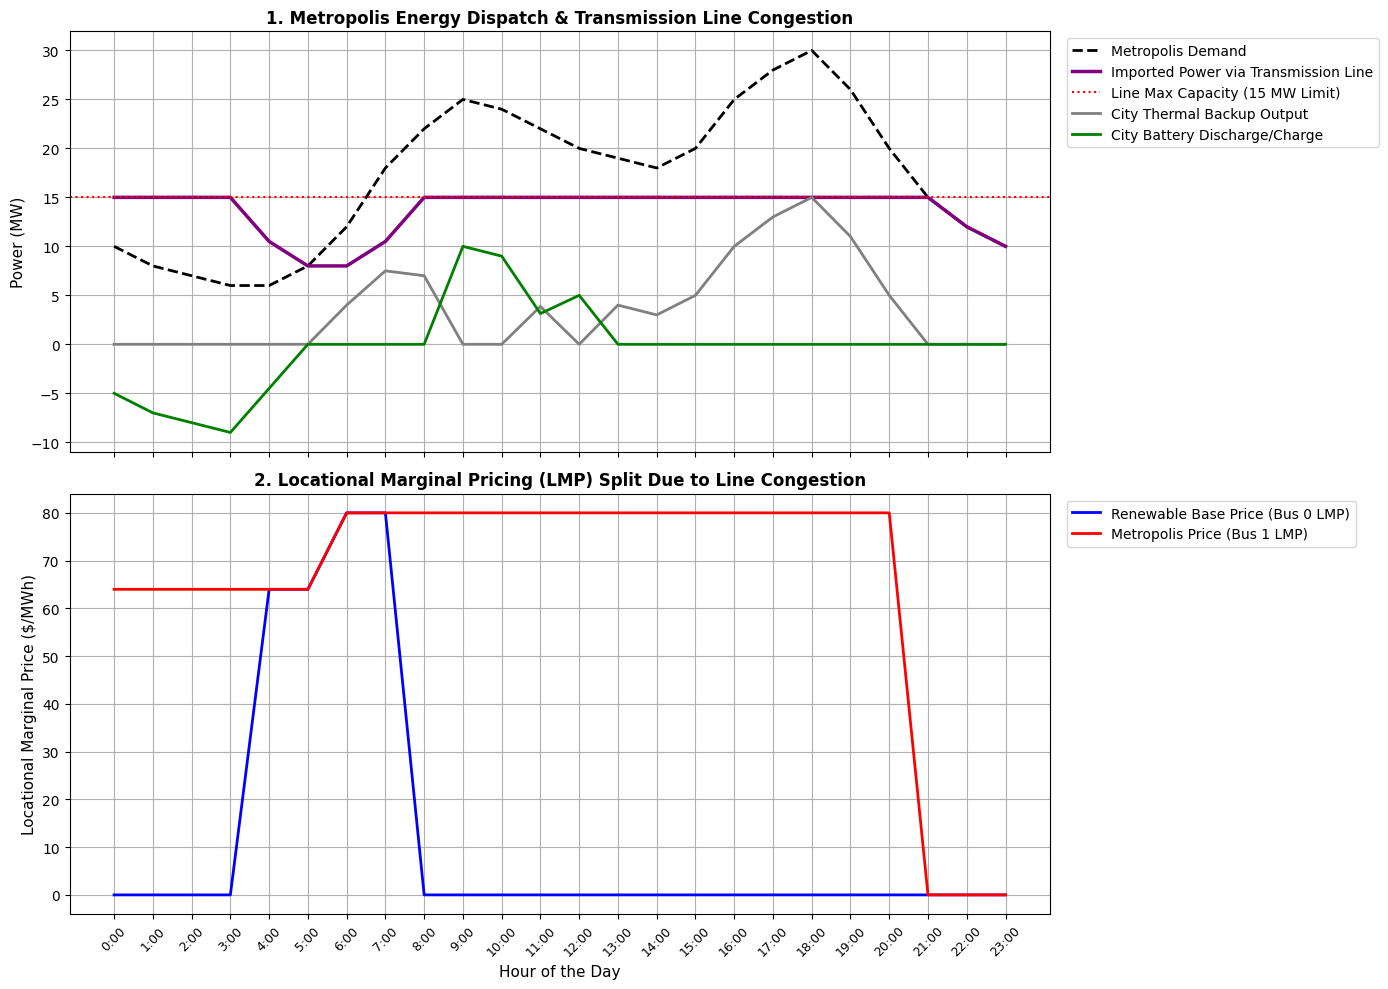

The lowest total cost of a cross-regional dual-node power grid throughout the day: $7,096.34 USD


In [ ]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

hours = pd.date_range("2024-07-01 00:00", periods=24, freq="h")

network = pypsa.Network()
network.set_snapshots(hours)

network.add("Bus", "Bus_Renewable_Base")

network.add("Bus", "Bus_Metropolis")

network.add("Line", "HV_Transmission_Line",
            bus0="Bus_Renewable_Base",
            bus1="Bus_Metropolis",
            s_nom=15,
            x=0.1)

city_load_profile = [10, 8, 7, 6, 6, 8, 12, 18, 22, 25, 24, 22, 20, 19, 18, 20, 25, 28, 30, 26, 20, 15, 12, 10]
network.add("Load", "Metropolis Load", bus="Bus_Metropolis", p_set=city_load_profile)

network.add("Load", "Base Local Load", bus="Bus_Renewable_Base", p_set=2)

solar_profile = [0, 0, 0, 0, 0, 0, 0.1, 0.3, 0.6, 0.8, 0.9, 1.0, 0.95, 0.85, 0.7, 0.4, 0.2, 0.05, 0, 0, 0, 0, 0, 0]
wind_profile = [0.8, 0.9, 0.85, 0.7, 0.5, 0.4, 0.3, 0.2, 0.2, 0.3, 0.4, 0.5, 0.5, 0.4, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0, 0.95, 0.9, 0.85]

network.add("Generator", "Base Solar", bus="Bus_Renewable_Base", p_nom=25, marginal_cost=0, p_max_pu=solar_profile)
network.add("Generator", "Base Wind", bus="Bus_Renewable_Base", p_nom=25, marginal_cost=0, p_max_pu=wind_profile)
network.add("Generator", "City Thermal Backup", bus="Bus_Metropolis", p_nom=50, marginal_cost=80)
network.add("StorageUnit", "City Battery", bus="Bus_Metropolis", p_nom=10, max_hours=4, efficiency_store=0.9, efficiency_dispatch=0.9, marginal_cost=1)

network.optimize(solver_name='highs')

line_flow = network.lines_t.p0["HV_Transmission_Line"]
lmp_base = network.buses_t.marginal_price["Bus_Renewable_Base"]
lmp_city = network.buses_t.marginal_price["Bus_Metropolis"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
hours_x = range(24)

ax1.plot(hours_x, network.loads_t.p["Metropolis Load"], 'k--', label="Metropolis Demand", linewidth=2)
ax1.plot(hours_x, line_flow, label="Imported Power via Transmission Line", color='purple', linewidth=2.5)
ax1.axhline(y=15, color='red', linestyle=':', label="Line Max Capacity (15 MW Limit)", linewidth=1.5)
ax1.plot(hours_x, network.generators_t.p["City Thermal Backup"], label="City Thermal Backup Output", color='gray', linewidth=2)
ax1.plot(hours_x, network.storage_units_t.p["City Battery"], label="City Battery Discharge/Charge", color='green', linewidth=2)
ax1.set_ylabel("Power (MW)", fontsize=11)
ax1.set_title("1. Metropolis Energy Dispatch & Transmission Line Congestion", fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax1.grid(True)

ax2.plot(hours_x, lmp_base, label="Renewable Base Price (Bus 0 LMP)", color='blue', linewidth=2)
ax2.plot(hours_x, lmp_city, label="Metropolis Price (Bus 1 LMP)", color='red', linewidth=2)
ax2.set_xticks(range(24))
ax2.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, fontsize=9)
ax2.set_xlabel("Hour of the Day", fontsize=11)
ax2.set_ylabel("Locational Marginal Price ($/MWh)", fontsize=11)
ax2.set_title("2. Locational Marginal Pricing (LMP) Split Due to Line Congestion", fontsize=12, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"The lowest total cost of a cross-regional dual-node power grid throughout the day: ${network.objective:,.2f} USD")

/tmp/ipykernel_651/1045341203.py:43: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Electricity Bus'], dtype='object', name='name')
/tmp/ipykernel_651/1045341203.py:43: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Electricity Bus'], dtype='object', name='name')
/tmp/ipykernel_651/1045341203.py:43: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves L

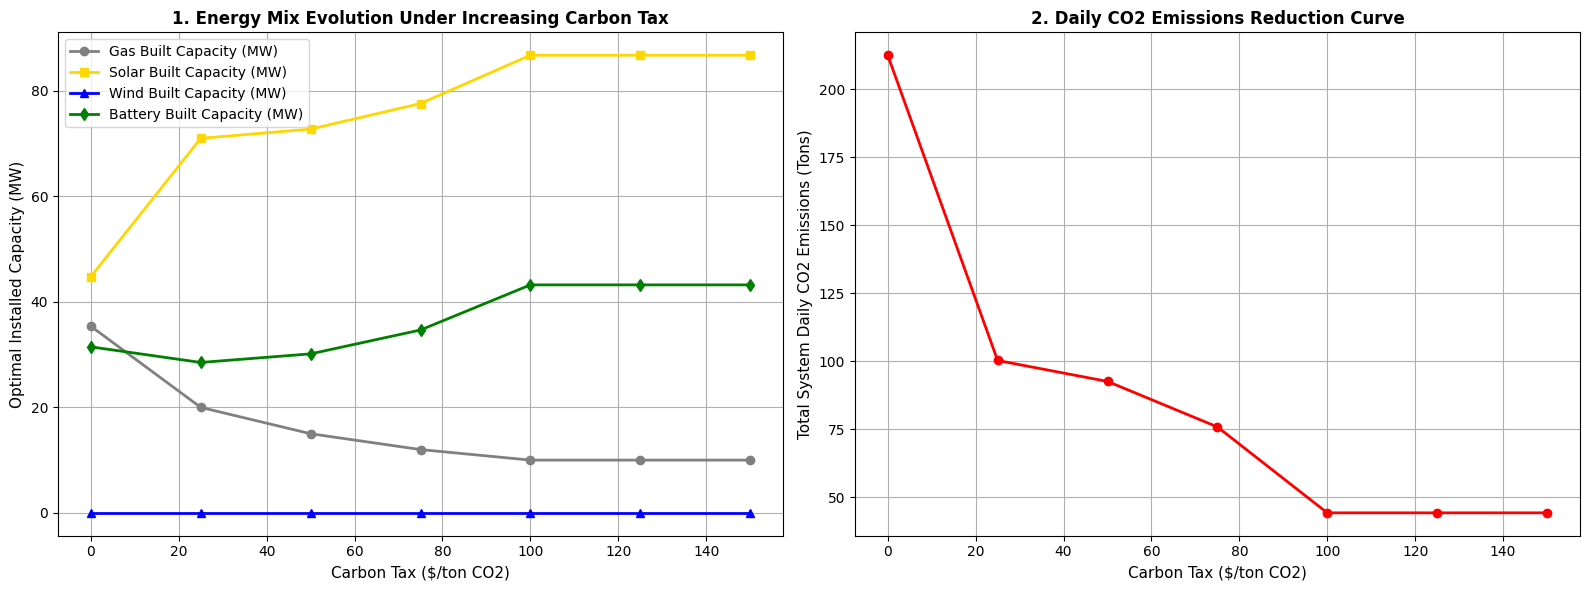

In [ ]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hours = pd.date_range("2024-07-01 00:00", periods=24, freq="h")

load_profile = [10, 8, 7, 6, 6, 8, 12, 18, 22, 25, 24, 22, 20, 19, 18, 20, 25, 28, 30, 26, 20, 15, 12, 10]
solar_profile = [0, 0, 0, 0, 0, 0, 0.1, 0.3, 0.5, 0.6, 0.65, 0.65, 0.6, 0.5, 0.35, 0.2, 0.1, 0.05, 0, 0, 0, 0, 0, 0]
wind_profile = [0.3, 0.3, 0.2, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.2, 0.2, 0.3]
tou_price_base = [30, 30, 30, 30, 30, 45, 70, 115, 115, 115, 115, 115, 70, 70, 70, 115, 115, 115, 115, 115, 70, 45, 30, 30]

carbon_taxes = [0, 25, 50, 75, 100, 125, 150]
co2_intensity = 0.9

opt_gas = []
opt_solar = []
opt_wind = []
opt_battery = []
total_co2_emissions = []

for tax in carbon_taxes:
    network = pypsa.Network()
    network.set_snapshots(hours)
    network.add("Bus", "Electricity Bus")

    network.add("Load", "City Load", bus="Electricity Bus", p_set=load_profile)

    effective_gas_price = [p + (co2_intensity * tax) for p in tou_price_base]

    network.add("Generator", "Gas Power Plant",
                bus="Electricity Bus", capital_cost=15, marginal_cost=effective_gas_price, p_nom_extendable=True)

    network.add("Generator", "Solar Plant",
                bus="Electricity Bus", capital_cost=200, marginal_cost=0, p_nom_extendable=True, p_max_pu=solar_profile)

    network.add("Generator", "Wind Plant",
                bus="Electricity Bus", capital_cost=500, marginal_cost=0, p_nom_extendable=True, p_max_pu=wind_profile)

    network.add("StorageUnit", "Battery",
                bus="Electricity Bus", max_hours=4, efficiency_store=0.9, efficiency_dispatch=0.9, capital_cost=260, marginal_cost=1, p_nom_extendable=True)

    network.optimize(solver_name='highs')

    opt_gas.append(network.generators.at['Gas Power Plant', 'p_nom_opt'])
    opt_solar.append(network.generators.at['Solar Plant', 'p_nom_opt'])
    opt_wind.append(network.generators.at['Wind Plant', 'p_nom_opt'])
    opt_battery.append(network.storage_units.at['Battery', 'p_nom_opt'])

    gas_gen_total = network.generators_t.p['Gas Power Plant'].sum()
    total_co2_emissions.append(gas_gen_total * co2_intensity)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(carbon_taxes, opt_gas, 'gray', marker='o', linewidth=2, label="Gas Built Capacity (MW)")
ax1.plot(carbon_taxes, opt_solar, 'gold', marker='s', linewidth=2, label="Solar Built Capacity (MW)")
ax1.plot(carbon_taxes, opt_wind, 'blue', marker='^', linewidth=2, label="Wind Built Capacity (MW)")
ax1.plot(carbon_taxes, opt_battery, 'green', marker='d', linewidth=2, label="Battery Built Capacity (MW)")
ax1.set_xlabel("Carbon Tax ($/ton CO2)", fontsize=11)
ax1.set_ylabel("Optimal Installed Capacity (MW)", fontsize=11)
ax1.set_title("1. Energy Mix Evolution Under Increasing Carbon Tax", fontsize=12, fontweight='bold')
ax1.legend(loc="best")
ax1.grid(True)

ax2.plot(carbon_taxes, total_co2_emissions, 'red', marker='o', linewidth=2)
ax2.set_xlabel("Carbon Tax ($/ton CO2)", fontsize=11)
ax2.set_ylabel("Total System Daily CO2 Emissions (Tons)", fontsize=11)
ax2.set_title("2. Daily CO2 Emissions Reduction Curve", fontsize=12, fontweight='bold')
ax2.grid(True)

plt.tight_layout()
plt.show()